<a href="https://colab.research.google.com/github/cs24dse016-design/CSL701-CS43_Machine-Learning-Lab/blob/main/Experiments/MLEXPerment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name : Khushi Harishchandra Pawar

Roll No.:CS43

#Aim

To implement a Multiple Linear Regression model from scratch using NumPy matrix operations to predict the selling price of used cars using multiple features from the CarDekho Used Car Dataset.

Task 1: Set Up the Python Environment

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully")

Libraries imported successfully


Task 2: Load and Inspect the Dataset

In [ ]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv("car data.csv")

print("First 5 records:")
display(df.head())

print("Number of rows and columns:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Saving car data.csv to car data.csv
First 5 records:


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


Number of rows and columns:
(301, 9)

Column names:
['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


Task 3: Check and Handle Missing Data

In [ ]:
print("Missing values in each column:")
print(df.isnull().sum())

print("\nTotal missing values:")
print(df.isnull().sum().sum())

Missing values in each column:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

Total missing values:
0


In [ ]:
df = df.dropna()

print("Missing values after preprocessing:")
print(df.isnull().sum())

print("\nDataset shape after removing missing values:")
print(df.shape)

Missing values after preprocessing:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

Dataset shape after removing missing values:
(301, 9)


Task 4: Select and Prepare Features

In [ ]:
print("Available columns:")
print(df.columns.tolist())

features = [
    "Present_Price",
    "Kms_Driven",
    "Fuel_Type",
    "Seller_Type",
    "Transmission",
    "Owner",
    "Year"
]

X = df[features].copy()
y = df["Selling_Price"].copy()

print("\nPredictor variables:")
display(X.head())

print("\nTarget variable:")
display(y.head())

Available columns:
['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']

Predictor variables:


,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Year
0,5.59,27000,Petrol,Dealer,Manual,0,2014
1,9.54,43000,Diesel,Dealer,Manual,0,2013
2,9.85,6900,Petrol,Dealer,Manual,0,2017
3,4.15,5200,Petrol,Dealer,Manual,0,2011
4,6.87,42450,Diesel,Dealer,Manual,0,2014



Target variable:


,Selling_Price
0,3.35
1,4.75
2,7.25
3,2.85
4,4.60


Task 5: Encode Categorical Variables

In [ ]:
print("Categorical columns:")
print(["Fuel_Type", "Seller_Type", "Transmission"])

X = pd.get_dummies(
    X,
    columns=["Fuel_Type", "Seller_Type", "Transmission"],
    drop_first=True
)

X = X.astype(float)

print("\nDataset after dummy encoding:")
display(X.head())

print("\nAll predictor columns:")
print(X.columns.tolist())

Categorical columns:
['Fuel_Type', 'Seller_Type', 'Transmission']

Dataset after dummy encoding:


,Present_Price,Kms_Driven,Owner,Year,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,5.59,27000.0,0.0,2014.0,0.0,1.0,0.0,1.0
1,9.54,43000.0,0.0,2013.0,1.0,0.0,0.0,1.0
2,9.85,6900.0,0.0,2017.0,0.0,1.0,0.0,1.0
3,4.15,5200.0,0.0,2011.0,0.0,1.0,0.0,1.0
4,6.87,42450.0,0.0,2014.0,1.0,0.0,0.0,1.0



All predictor columns:
['Present_Price', 'Kms_Driven', 'Owner', 'Year', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Seller_Type_Individual', 'Transmission_Manual']


Task 6: Perform Feature Engineering

In [ ]:
CURRENT_YEAR = 2026

df["Car_Age"] = CURRENT_YEAR - df["Year"]

print("Year and Car_Age:")
display(df[["Year", "Car_Age"]].head(10))

Year and Car_Age:


,Year,Car_Age
0,2014,12
1,2013,13
2,2017,9
3,2011,15
4,2014,12
5,2018,8
6,2015,11
7,2015,11
8,2016,10
9,2015,11


In [ ]:
X["Car_Age"] = df["Car_Age"]

# Remove original Year because Car_Age contains the same information
X = X.drop(columns=["Year"])

print("Final features after feature engineering:")
print(X.columns.tolist())

display(X.head())

Final features after feature engineering:
['Present_Price', 'Kms_Driven', 'Owner', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Seller_Type_Individual', 'Transmission_Manual', 'Car_Age']


,Present_Price,Kms_Driven,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual,Car_Age
0,5.59,27000.0,0.0,0.0,1.0,0.0,1.0,12
1,9.54,43000.0,0.0,1.0,0.0,0.0,1.0,13
2,9.85,6900.0,0.0,0.0,1.0,0.0,1.0,9
3,4.15,5200.0,0.0,0.0,1.0,0.0,1.0,15
4,6.87,42450.0,0.0,1.0,0.0,0.0,1.0,12


Task 7: Perform Exploratory Data Analysis

Plot 1: Present Price vs Selling Price

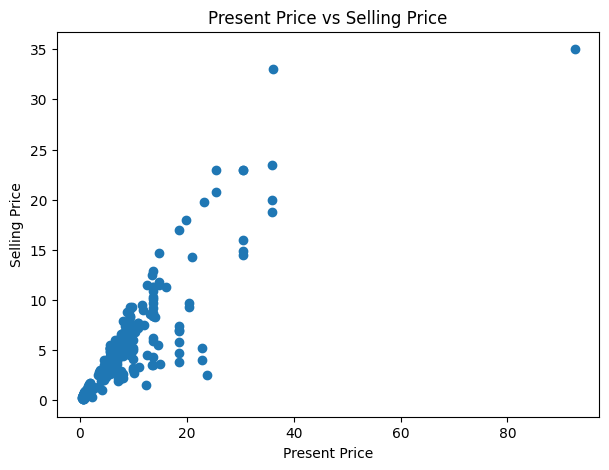

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(
    df["Present_Price"],
    df["Selling_Price"]
)

plt.xlabel("Present Price")
plt.ylabel("Selling Price")
plt.title("Present Price vs Selling Price")

plt.show()

Plot 2: Kms Driven vs Selling Price

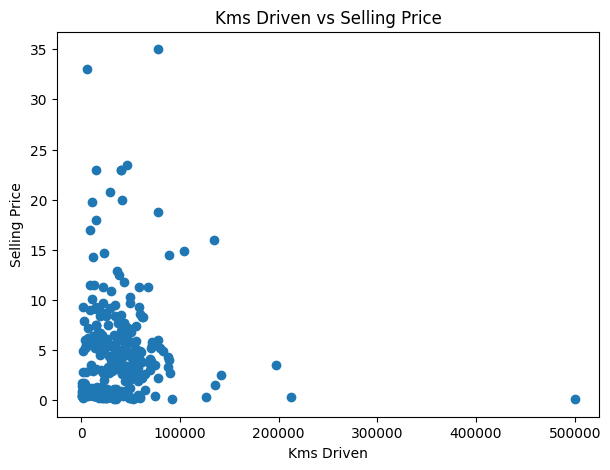

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(
    df["Kms_Driven"],
    df["Selling_Price"]
)

plt.xlabel("Kms Driven")
plt.ylabel("Selling Price")
plt.title("Kms Driven vs Selling Price")

plt.show()

Task 8: Standardize Numerical Features

The experiment specifies:

z = (x − μ) / σ

and requires that mean and standard deviation be calculated using training data only.

We first need to split the data.

Task 9: Split the Dataset

In [ ]:
np.random.seed(42)

indices = np.random.permutation(len(X))

train_size = int(0.8 * len(X))

train_indices = indices[:train_size]
test_indices = indices[train_size:]

X_train = X.iloc[train_indices].values
X_test = X.iloc[test_indices].values

y_train = y.iloc[train_indices].values
y_test = y.iloc[test_indices].values

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

Training observations: 240
Testing observations: 61


Task 8 Continued: Standardize Numerical Features

In [ ]:
numeric_features = [
    "Present_Price",
    "Kms_Driven",
    "Owner",
    "Car_Age"
]

numeric_indices = [
    X.columns.get_loc(feature)
    for feature in numeric_features
]

# Calculate mean and standard deviation from training data only
means = X_train[:, numeric_indices].mean(axis=0)
stds = X_train[:, numeric_indices].std(axis=0)

# Avoid division by zero
stds[stds == 0] = 1

# Standardize training data
X_train[:, numeric_indices] = (
    X_train[:, numeric_indices] - means
) / stds

# Standardize test data using training mean and std
X_test[:, numeric_indices] = (
    X_test[:, numeric_indices] - means
) / stds

print("Numerical features standardized successfully.")

Numerical features standardized successfully.


Task 10: Construct the Feature Matrix

In [ ]:
print("Xtrain shape:", X_train.shape)
print("ytrain shape:", y_train.shape)

print("Xtest shape:", X_test.shape)
print("ytest shape:", y_test.shape)

print("\nNumber of predictor columns:", X_train.shape[1])

Xtrain shape: (240, 8)
ytrain shape: (240,)
Xtest shape: (61, 8)
ytest shape: (61,)

Number of predictor columns: 8


Task 11: Add Bias/Intercept Term

In [ ]:
X_train = np.column_stack(
    (np.ones(X_train.shape[0]), X_train)
)

X_test = np.column_stack(
    (np.ones(X_test.shape[0]), X_test)
)

print("X_train shape after adding bias:", X_train.shape)
print("X_test shape after adding bias:", X_test.shape)

print("\nFirst 5 rows of X_train:")
print(X_train[:5])

X_train shape after adding bias: (240, 9)
X_test shape after adding bias: (61, 9)

First 5 rows of X_train:
[[ 1.         -0.7904357  -0.33334052 -0.12631593  0.          1.
   1.          0.         -0.83981989]
 [ 1.          0.64741063 -0.64683049 -0.12631593  0.          1.
   0.          1.         -0.83981989]
 [ 1.          0.1839452   0.53345202 -0.12631593  1.          0.
   0.          1.          0.52898672]
 [ 1.         -0.7904357  -0.06848724  4.20451603  0.          1.
   1.          1.          0.87118837]
 [ 1.          1.20025869  0.05192469 -0.12631593  0.          1.
   0.          1.          0.18678507]]


Task 12: Implement the OLS Function

In [ ]:
def ols(X, y):
    XTX = X.T @ X
    XTy = X.T @ y

    beta = np.linalg.inv(XTX) @ XTy

    return beta

Task 13: Check Matrix Singularity

In [ ]:
XTX = X_train.T @ X_train

determinant = np.linalg.det(XTX)

print("Determinant of X^T X:")
print(determinant)

if np.isclose(determinant, 0):
    print("X^T X is singular or nearly singular.")
else:
    print("X^T X is not singular.")

Determinant of X^T X:
2.788300430377448e+16
X^T X is not singular.


Task 14: Train the Regression Model

In [ ]:
beta = ols(X_train, y_train)

print("Regression coefficient vector:")
print(beta)

print("\nIntercept (Beta 0):")
print(beta[0])

Regression coefficient vector:
[ 5.38253929  3.93031589 -0.22819014 -0.19120934  2.48129461  0.56061133
 -1.11909315 -1.4784026  -1.22971617]

Intercept (Beta 0):
5.382539292411748


In [ ]:
feature_names = ["Intercept"] + X.columns.tolist()

print("Regression coefficients:\n")

for feature, coefficient in zip(feature_names, beta):
    print(f"{feature}: {coefficient:.6f}")

Regression coefficients:

Intercept: 5.382539
Present_Price: 3.930316
Kms_Driven: -0.228190
Owner: -0.191209
Fuel_Type_Diesel: 2.481295
Fuel_Type_Petrol: 0.560611
Seller_Type_Individual: -1.119093
Transmission_Manual: -1.478403
Car_Age: -1.229716


Task 15: Interpret the Regression Coefficients

In [ ]:
print("Coefficient Interpretation:\n")

for feature, coefficient in zip(feature_names, beta):

    if coefficient > 0:
        sign = "Positive"
    elif coefficient < 0:
        sign = "Negative"
    else:
        sign = "Zero"

    print(
        f"{feature}: {coefficient:.6f} --> {sign}"
    )

Coefficient Interpretation:

Intercept: 5.382539 --> Positive
Present_Price: 3.930316 --> Positive
Kms_Driven: -0.228190 --> Negative
Owner: -0.191209 --> Negative
Fuel_Type_Diesel: 2.481295 --> Positive
Fuel_Type_Petrol: 0.560611 --> Positive
Seller_Type_Individual: -1.119093 --> Negative
Transmission_Manual: -1.478403 --> Negative
Car_Age: -1.229716 --> Negative


In [ ]:
coefficient_table = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": beta
})

coefficient_table["Absolute_Coefficient"] = np.abs(
    coefficient_table["Coefficient"]
)

coefficient_table = coefficient_table.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

display(coefficient_table)

,Feature,Coefficient,Absolute_Coefficient
0,Intercept,5.382539,5.382539
1,Present_Price,3.930316,3.930316
4,Fuel_Type_Diesel,2.481295,2.481295
7,Transmission_Manual,-1.478403,1.478403
8,Car_Age,-1.229716,1.229716
6,Seller_Type_Individual,-1.119093,1.119093
5,Fuel_Type_Petrol,0.560611,0.560611
2,Kms_Driven,-0.228190,0.228190
3,Owner,-0.191209,0.191209


Task 16: Predict Selling Prices

In [ ]:
y_pred = X_test @ beta

comparison = pd.DataFrame({
    "Actual Selling Price": y_test,
    "Predicted Selling Price": y_pred
})

print("Actual vs Predicted Selling Prices:")
display(comparison.head(10))

Actual vs Predicted Selling Prices:


,Actual Selling Price,Predicted Selling Price
0,4.00,4.770912
1,2.55,1.879784
2,5.30,4.392618
3,3.25,3.569613
4,0.45,0.646852
5,5.50,6.698899
6,3.15,4.214598
7,0.60,-0.179732
8,0.20,-2.114263
9,3.50,4.506359


Task 17: Calculate Prediction Errors and RSS

In [ ]:
residuals = y_test - y_pred

RSS = np.sum(residuals ** 2)

print("Residuals:")
print(residuals[:10])

print("\nResidual Sum of Squares (RSS):")
print(RSS)

Residuals:
[-0.77091208  0.67021582  0.90738198 -0.31961315 -0.19685199 -1.19889891
 -1.0645978   0.77973206  2.31426287 -1.00635942]

Residual Sum of Squares (RSS):
107.6385518742813


Task 18: Calculate and Interpret R²

In [ ]:
TSS = np.sum(
    (y_test - np.mean(y_test)) ** 2
)

R2 = 1 - (RSS / TSS)

print("Total Sum of Squares (TSS):")
print(TSS)

print("\nR²:")
print(R2)

Total Sum of Squares (TSS):
1090.019380327869

R²:
0.9012507907502484


In [ ]:
print(
    f"\nThe model explains approximately {R2 * 100:.2f}% "
    "of the variation in selling prices."
)


The model explains approximately 90.13% of the variation in selling prices.


Task 19: Visualize and Analyze Model Performance

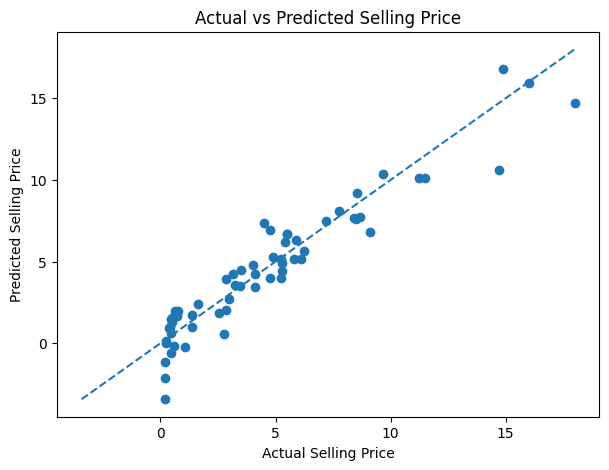

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(
    y_test,
    y_pred
)

minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price")

plt.show()

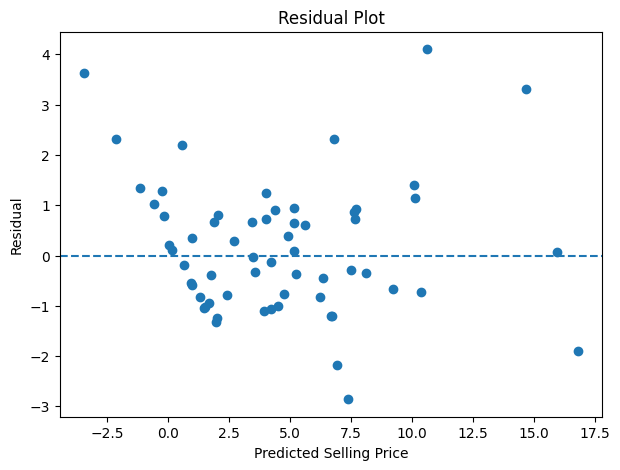

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(
    y_pred,
    residuals
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Selling Price")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

In [ ]:
error_table = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred,
    "Residual": residuals,
    "Absolute Error": np.abs(residuals)
})

error_table = error_table.sort_values(
    by="Absolute Error",
    ascending=False
)

print("Observations with largest prediction errors:")

display(error_table.head(10))

Observations with largest prediction errors:


,Actual,Predicted,Residual,Absolute Error
18,14.73,10.627893,4.102107,4.102107
34,0.20,-3.427291,3.627291,3.627291
22,18.00,14.687546,3.312454,3.312454
57,4.50,7.357733,-2.857733,2.857733
8,0.20,-2.114263,2.314263,2.314263
40,9.10,6.790153,2.309847,2.309847
31,2.75,0.561336,2.188664,2.188664
16,4.75,6.935247,-2.185247,2.185247
32,14.90,16.791991,-1.891991,1.891991
35,11.50,10.089066,1.410934,1.410934


Task 20: Conclude

In [ ]:
print("======================================")
print("        FINAL EXPERIMENT RESULTS")
print("======================================")

print("Training samples:", len(y_train))
print("Testing samples:", len(y_test))

print("RSS:", RSS)
print("R²:", R2)
print("R² Percentage:", R2 * 100, "%")

print("\nMost influential features:")
display(
    coefficient_table[
        ["Feature", "Coefficient"]
    ].head(5)
)

        FINAL EXPERIMENT RESULTS
Training samples: 240
Testing samples: 61
RSS: 107.6385518742813
R²: 0.9012507907502484
R² Percentage: 90.12507907502484 %

Most influential features:


,Feature,Coefficient
0,Intercept,5.382539
1,Present_Price,3.930316
4,Fuel_Type_Diesel,2.481295
7,Transmission_Manual,-1.478403
8,Car_Age,-1.229716


Conclusion:

Multiple Linear Regression was successfully implemented using NumPy and the OLS method. The model predicted used-car selling prices using multiple features, and its performance was evaluated using RSS and R². The experiment demonstrated the effectiveness of Multiple Linear Regression for price prediction.

